In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
# =============================================================
# 1. LOAD DATA
# =============================================================
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
print("Shape awal:", data.shape)
print(data['CVD_LABEL'].value_counts())

Shape awal: (438693, 304)
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64


In [100]:
# =============================================================
# 2. HAPUS KOLOM MISSING VALUES >= 30%
# =============================================================
miss = data.isnull().mean() * 100
cols_to_drop_miss = miss[miss >= 30].index.tolist()

print(f"\nKolom dihapus karena missing >= 30% ({len(cols_to_drop_miss)}):")
print(cols_to_drop_miss)

data1 = data.drop(columns=cols_to_drop_miss)
print(f"\nShape setelah hapus missing: {data1.shape}")


Kolom dihapus karena missing >= 30% (155):
['CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'COLGSEX', 'NUMADULT', 'LANDSEX', 'NUMMEN', 'NUMWOMEN', 'RESPSLCT', 'CCLGHOUS', 'POORHLTH', 'BPMEDS', 'ASTHNOW', 'DIABAGE3', 'ARTHEXER', 'ARTHEDU', 'LMTJOIN3', 'ARTHDIS2', 'JOINPAI2', 'NUMHHOL3', 'NUMPHON3', 'PREGNANT', 'SMOKDAY2', 'AVEDRNK3', 'DRNK3GE5', 'MAXDRNKS', 'FLSHTMY3', 'IMFVPLA2', 'HIVTSTD3', 'PDIABTST', 'PREDIAB1', 'INSULIN1', 'BLDSUGAR', 'FEETCHK3', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'EYEEXAM1', 'DIABEYE', 'DIABEDU', 'TOLDCFS', 'HAVECFS', 'WORKCFS', 'TOLDHEPC', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'HAVEHEPB', 'MEDSHEPB', 'HPVADVC4', 'HPVADSHT', 'TETANUS1', 'SHINGLE2', 'LCSFIRST', 'LCSLAST', 'LCSNUMCG', 'LCSCTSCN', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'PSATEST1', 'PSATIME1', 'PCPSARS2', 'PCSTALK', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES1', 'SMALSTOL', 'STOLTEST', 'ST

In [101]:
# ============================================================
# DEFINISI FITUR (sudah deduplikasi)
# ============================================================
fitur_paper = [
    # --- Cardiovascular / Target ---
    'CVD_LABEL',    # Label/Target
    '_MICHD',       # Heart Problems (CHD/MI)
    'CVDSTRK3',     # Stroke
    'CVDCRHD4',     # Coronary Heart Disease
    'CVDINFR4',     # Heart Attack

    # --- Blood Pressure & Cholesterol ---
    '_RFHYPE6',     # High Blood Pressure (calculated)
    'BPHIGH6',      # Ever Told Blood Pressure High
    'TOLDHI3',      # High Cholesterol
    '_CHOLCH3',     # Cholesterol Check (calculated)
    'CHOLCHK3',     # Cholesterol Check (raw)

    # --- Metabolic & Chronic Conditions ---
    'DIABETE4',     # Diabetes
    'CHCKDNY2',     # Kidney Disease
    'CHCCOPD3',     # COPD
    'ASTHMA3',      # Asthma
    'ADDEPEV3',     # Depression
    '_DRDXAR3',     # Arthritis

    # --- BMI ---
    '_BMI5',        # BMI (continuous)
    '_BMI5CAT',     # BMI Category

    # --- Lifestyle ---
    'SMOKE100',     # Smoker
    '_TOTINDA',     # Physical Activity
    '_FRTLT1A',     # Fruits Consumption
    '_VEGLT1A',     # Veggies Consumption
    '_DRNKWK1',     # Alcohol Consumption

    # --- Health Status ---
    'GENHLTH',      # General Health
    'MENTHLTH',     # Mental Health
    'PHYSHLTH',     # Physical Health
    'DIFFWALK',     # Difficulty Walking
    'DECIDE',       # Difficulty Concentrating/Deciding

    # --- Healthcare Access ---
    '_HLTHPLN',     # Any Healthcare Coverage
    'MEDCOST1',     # No Doc because Cost
    'PERSDOC3',     # Personal Doctor
    'CHECKUP1',     # Last Routine Checkup

    # --- Preventive Care ---
    'PNEUVAC4',     # Pneumonia Vaccine
    'FLUSHOT7',     # Flu Shot
    '_AIDTST4',     # HIV Test

    # --- Demographics ---
    '_SEX',         # Sex
    '_AGEG5YR',     # Age Group
    'EDUCA',        # Education
    'INCOME3',      # Income
    'EMPLOY1',      # Employment Status
    '_PRACE1',      # Race
]

# Hapus duplikat sambil pertahankan urutan
fitur_paper = list(dict.fromkeys(fitur_paper))

# ============================================================
# CEK KOLOM DIABETES
# ============================================================
diabetes_cols = [c for c in data1.columns if 'DIAB' in c.upper()]
print("Kolom diabetes yang tersedia:", diabetes_cols)

# ============================================================
# CEK KETERSEDIAAN FITUR
# ============================================================
fitur_exist   = [c for c in fitur_paper if c in data1.columns]
fitur_missing = [c for c in fitur_paper if c not in data1.columns]

print(f"\n{'='*45}")
print(f"  Total fitur didefinisikan : {len(fitur_paper)}")
print(f"  Fitur ditemukan           : {len(fitur_exist)}")
print(f"  Fitur tidak ditemukan     : {len(fitur_missing)}")
print(f"{'='*45}")

if fitur_missing:
    print("\n⚠️  Fitur yang TIDAK ADA di dataset:")
    for i, col in enumerate(fitur_missing, 1):
        print(f"   {i:2}. {col}")

# ============================================================
# BUAT DATASET FINAL
# ============================================================
data_final = data1[fitur_exist].copy()

print(f"\n✅ Shape data final : {data_final.shape}")
print(f"\nFitur yang dipakai ({len(fitur_exist)} fitur):")
for i, col in enumerate(fitur_exist, 1):
    print(f"  {i:2}. {col}")

Kolom diabetes yang tersedia: ['DIABETE4']

  Total fitur didefinisikan : 41
  Fitur ditemukan           : 41
  Fitur tidak ditemukan     : 0

✅ Shape data final : (438693, 41)

Fitur yang dipakai (41 fitur):
   1. CVD_LABEL
   2. _MICHD
   3. CVDSTRK3
   4. CVDCRHD4
   5. CVDINFR4
   6. _RFHYPE6
   7. BPHIGH6
   8. TOLDHI3
   9. _CHOLCH3
  10. CHOLCHK3
  11. DIABETE4
  12. CHCKDNY2
  13. CHCCOPD3
  14. ASTHMA3
  15. ADDEPEV3
  16. _DRDXAR3
  17. _BMI5
  18. _BMI5CAT
  19. SMOKE100
  20. _TOTINDA
  21. _FRTLT1A
  22. _VEGLT1A
  23. _DRNKWK1
  24. GENHLTH
  25. MENTHLTH
  26. PHYSHLTH
  27. DIFFWALK
  28. DECIDE
  29. _HLTHPLN
  30. MEDCOST1
  31. PERSDOC3
  32. CHECKUP1
  33. PNEUVAC4
  34. FLUSHOT7
  35. _AIDTST4
  36. _SEX
  37. _AGEG5YR
  38. EDUCA
  39. INCOME3
  40. EMPLOY1
  41. _PRACE1


## Preprocessing 1

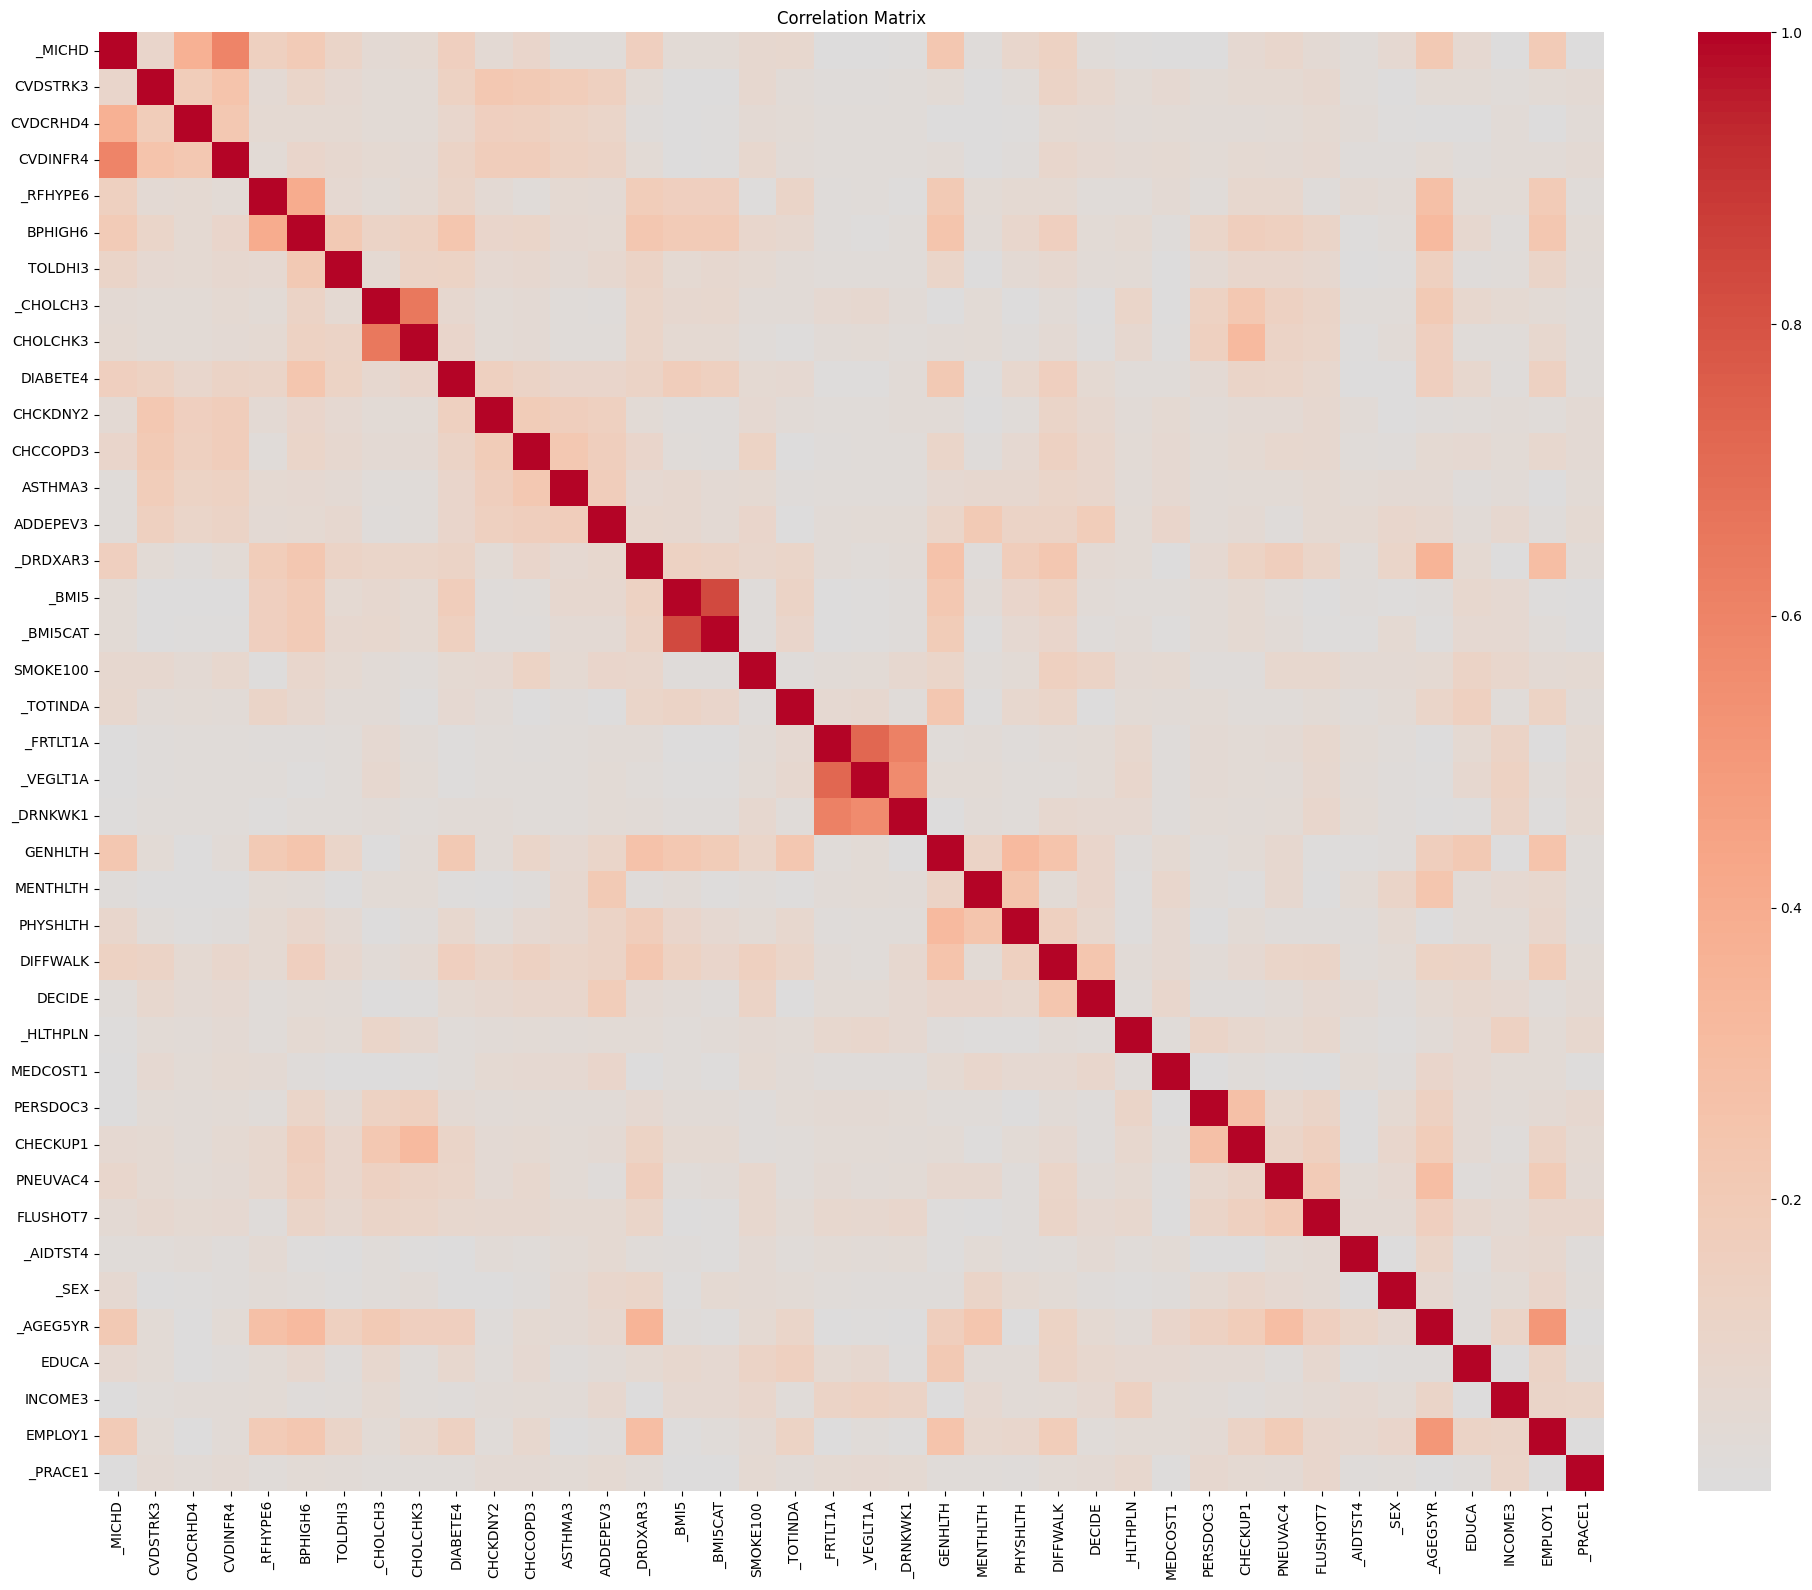

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
corr_matrix = data_final.select_dtypes(include='float64').corr().abs()

# Visualisasi heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm',
            center=0,
            annot=False,  # ganti True kalau mau lihat angkanya (lambat kalau banyak fitur)
            fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [103]:
# Tampilkan pasangan fitur dengan korelasi > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.50]

high_corr_df = pd.DataFrame(high_corr, columns=['Fitur_1', 'Fitur_2', 'Korelasi'])
high_corr_df = high_corr_df.sort_values('Korelasi', ascending=False)

print(f"Pasangan fitur dengan korelasi > 0.85: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Pasangan fitur dengan korelasi > 0.85: 7
 Fitur_1  Fitur_2  Korelasi
_BMI5CAT    _BMI5  0.830420
_VEGLT1A _FRTLT1A  0.721476
CHOLCHK3 _CHOLCH3  0.648654
_DRNKWK1 _FRTLT1A  0.609881
CVDINFR4   _MICHD  0.600431
_DRNKWK1 _VEGLT1A  0.569375
 EMPLOY1 _AGEG5YR  0.511347


In [104]:
data_final = data_final.drop(columns=['_BMI5CAT'])

In [105]:
# Cara 1 - Value counts semua kolom sekaligus
for col in data_final.columns:
    print(f"\n{'='*50}")
    print(f"Kolom: {col}")
    print(data_final[col].value_counts(dropna=False))


Kolom: CVD_LABEL
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64

Kolom: _MICHD
_MICHD
2.0    398735
1.0     35323
NaN      4635
Name: count, dtype: int64

Kolom: CVDSTRK3
CVDSTRK3
2.0    420051
1.0     17213
7.0      1130
9.0       297
NaN         2
Name: count, dtype: int64

Kolom: CVDCRHD4
CVDCRHD4
2.0    411527
1.0     22891
7.0      3934
9.0       339
NaN         2
Name: count, dtype: int64

Kolom: CVDINFR4
CVDINFR4
2.0    413207
1.0     22831
7.0      2319
9.0       334
NaN         2
Name: count, dtype: int64

Kolom: _RFHYPE6
_RFHYPE6
1.0    264648
2.0    172133
9.0      1912
Name: count, dtype: int64

Kolom: BPHIGH6
BPHIGH6
3.0    256603
1.0    172133
4.0      4571
2.0      3474
7.0      1191
9.0       719
NaN         2
Name: count, dtype: int64

Kolom: TOLDHI3
TOLDHI3


In [106]:
import pandas as pd
import numpy as np

# Nilai yang perlu diganti NaN per variabel
nan_map = {
    'CVDSTRK3':  [7.0, 9.0],
    'CVDCRHD4':  [7.0, 9.0],
    'CVDINFR4':  [7.0, 9.0],
    'BPHIGH6':   [7.0, 9.0],
    'TOLDHI3':   [7.0, 9.0],
    '_CHOLCH3':  [9.0],
    'CHOLCHK3':  [7.0, 9.0],
    'DIABETE4':  [7.0, 9.0],
    'CHCKDNY2':  [7.0, 9.0],
    'CHCCOPD3':  [7.0, 9.0],
    'ASTHMA3':   [7.0, 9.0],
    'ADDEPEV3':  [7.0, 9.0],
    '_DRDXAR3':  [],           # sudah NaN semua
    'SMOKE100':  [7.0, 9.0],
    '_TOTINDA':  [9.0],
    '_FRTLT1A':  [9.0],
    '_VEGLT1A':  [9.0],
    'GENHLTH':   [7.0, 9.0],
    'MENTHLTH':  [77.0, 99.0],
    'PHYSHLTH':  [77.0, 99.0],
    'DIFFWALK':  [7.0, 9.0],
    'DECIDE':    [7.0, 9.0],
    '_HLTHPLN':  [9.0],
    'MEDCOST1':  [7.0, 9.0],
    'PERSDOC3':  [7.0, 9.0],
    'CHECKUP1':  [7.0, 8.0, 9.0],
    'PNEUVAC4':  [7.0, 9.0],
    'FLUSHOT7':  [7.0, 9.0],
    '_AIDTST4':  [9.0],
    'EDUCA':     [9.0],
    'INCOME3':   [77.0, 99.0],
    'EMPLOY1':   [9.0],
    '_PRACE1':   [77.0, 99.0],
}

for col, invalid_vals in nan_map.items():
    if col in data_final.columns and invalid_vals:
        data_final[col] = data_final[col].replace(invalid_vals, np.nan)

print("Selesai! Cek missing values:")
print(data_final[nan_map.keys()].isna().sum())

Selesai! Cek missing values:
CVDSTRK3     1429
CVDCRHD4     4275
CVDINFR4     2655
BPHIGH6      1912
TOLDHI3     63980
_CHOLCH3    29782
CHOLCHK3    29782
DIABETE4      985
CHCKDNY2     1813
CHCCOPD3     2107
ASTHMA3      1746
ADDEPEV3     2517
_DRDXAR3     2896
SMOKE100    24461
_TOTINDA      928
_FRTLT1A    51087
_VEGLT1A    60127
GENHLTH      1161
MENTHLTH     7917
PHYSHLTH     9494
DIFFWALK    19830
DECIDE      19980
_HLTHPLN    17397
MEDCOST1     1364
PERSDOC3     3705
CHECKUP1     8216
PNEUVAC4    62801
FLUSHOT7    31392
_AIDTST4    51856
EDUCA        2478
INCOME3     94413
EMPLOY1      8251
_PRACE1     13363
dtype: int64


In [107]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Data columns (total 40 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CVD_LABEL  438693 non-null  object 
 1   _MICHD     434058 non-null  float64
 2   CVDSTRK3   437264 non-null  float64
 3   CVDCRHD4   434418 non-null  float64
 4   CVDINFR4   436038 non-null  float64
 5   _RFHYPE6   438693 non-null  float64
 6   BPHIGH6    436781 non-null  float64
 7   TOLDHI3    374713 non-null  float64
 8   _CHOLCH3   408911 non-null  float64
 9   CHOLCHK3   408911 non-null  float64
 10  DIABETE4   437708 non-null  float64
 11  CHCKDNY2   436880 non-null  float64
 12  CHCCOPD3   436586 non-null  float64
 13  ASTHMA3    436947 non-null  float64
 14  ADDEPEV3   436176 non-null  float64
 15  _DRDXAR3   435797 non-null  float64
 16  _BMI5      391841 non-null  float64
 17  SMOKE100   414232 non-null  float64
 18  _TOTINDA   437765 non-null  float64
 19  _FRTLT1A   387606 non-n

In [108]:
data_final.describe()

,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,...,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1
count,434058.000000,437264.000000,434418.000000,436038.000000,438693.000000,436781.000000,374713.000000,408911.000000,408911.000000,437708.000000,...,430477.000000,375892.000000,407301.000000,386837.000000,438693.000000,438693.000000,436215.000000,344280.000000,430442.000000,425330.000000
mean,1.918621,1.960635,1.947307,1.947640,1.427244,2.214323,1.600430,1.186539,2.405142,2.750752,...,1.356802,1.596778,1.479098,1.666506,1.535529,7.726016,5.012790,6.698330,3.747225,1.431935
std,0.273416,0.194463,0.223421,0.222752,0.699127,0.988691,0.489811,0.552422,1.300781,0.704141,...,0.772044,0.490545,0.499564,0.471462,0.498737,3.645926,1.007272,2.422855,2.837228,1.143380
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,4.000000,5.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,2.000000,1.000000,2.000000,2.000000,8.000000,5.000000,7.000000,2.000000,1.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,11.000000,6.000000,9.000000,7.000000,1.000000
max,2.000000,2.000000,2.000000,2.000000,9.000000,4.000000,2.000000,3.000000,8.000000,4.000000,...,4.000000,2.000000,2.000000,2.000000,2.000000,14.000000,6.000000,11.000000,8.000000,8.000000


In [109]:
data_final.isna().sum()

CVD_LABEL        0
_MICHD        4635
CVDSTRK3      1429
CVDCRHD4      4275
CVDINFR4      2655
_RFHYPE6         0
BPHIGH6       1912
TOLDHI3      63980
_CHOLCH3     29782
CHOLCHK3     29782
DIABETE4       985
CHCKDNY2      1813
CHCCOPD3      2107
ASTHMA3       1746
ADDEPEV3      2517
_DRDXAR3      2896
_BMI5        46852
SMOKE100     24461
_TOTINDA       928
_FRTLT1A     51087
_VEGLT1A     60127
_DRNKWK1         0
GENHLTH       1161
MENTHLTH      7917
PHYSHLTH      9494
DIFFWALK     19830
DECIDE       19980
_HLTHPLN     17397
MEDCOST1      1364
PERSDOC3      3705
CHECKUP1      8216
PNEUVAC4     62801
FLUSHOT7     31392
_AIDTST4     51856
_SEX             0
_AGEG5YR         0
EDUCA         2478
INCOME3      94413
EMPLOY1       8251
_PRACE1      13363
dtype: int64

In [110]:
severity_map = {
    'Healt'            : 0,  # Sehat
    'Stroke Only'       : 1,  # Level 1 → 1 kondisi
    'CHD Only'          : 1,  # Level 1 → 1 kondisi
    'Heart Attack Only' : 1,  # Level 1 → 1 kondisi
    'MI + CHD'          : 1,  # Level 2 → 2 kondisi
    'MI + Stroke'       : 1,  # Level 2 → 2 kondisi
    'CHD + Stroke'      : 1,  # Level 2 → 2 kondisi
    'All Three'         : 1,  # Level 3 → 3 kondisi
}

data_final['CVD_SEVERITY'] = data_final['CVD_LABEL'].map(severity_map)

# Verifikasi
print(data_final['CVD_SEVERITY'].value_counts())
print(f"\nTotal : {len(data1):,}")

CVD_SEVERITY
0    391852
1     46841
Name: count, dtype: int64

Total : 438,693


In [111]:
data_final.isnull().sum()

CVD_LABEL           0
_MICHD           4635
CVDSTRK3         1429
CVDCRHD4         4275
CVDINFR4         2655
_RFHYPE6            0
BPHIGH6          1912
TOLDHI3         63980
_CHOLCH3        29782
CHOLCHK3        29782
DIABETE4          985
CHCKDNY2         1813
CHCCOPD3         2107
ASTHMA3          1746
ADDEPEV3         2517
_DRDXAR3         2896
_BMI5           46852
SMOKE100        24461
_TOTINDA          928
_FRTLT1A        51087
_VEGLT1A        60127
_DRNKWK1            0
GENHLTH          1161
MENTHLTH         7917
PHYSHLTH         9494
DIFFWALK        19830
DECIDE          19980
_HLTHPLN        17397
MEDCOST1         1364
PERSDOC3         3705
CHECKUP1         8216
PNEUVAC4        62801
FLUSHOT7        31392
_AIDTST4        51856
_SEX                0
_AGEG5YR            0
EDUCA            2478
INCOME3         94413
EMPLOY1          8251
_PRACE1         13363
CVD_SEVERITY        0
dtype: int64

In [112]:
data_final

,CVD_LABEL,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,...,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1,CVD_SEVERITY
0,Healt,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,...,1.0,1.0,2.0,2.0,11.0,4.0,5.0,7.0,1.0,0
1,CHD Only,1.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,10.0,6.0,NaN,8.0,2.0,1
2,CHD Only,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,11.0,4.0,3.0,7.0,2.0,1
3,Healt,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,...,2.0,1.0,2.0,2.0,9.0,4.0,7.0,7.0,1.0,0
4,MI + Stroke,1.0,1.0,NaN,1.0,1.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,12.0,3.0,4.0,8.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,6.0,...,1.0,2.0,1.0,2.0,3.0,4.0,5.0,1.0,NaN,0
438689,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,1.0,13.0,4.0,1.0,8.0,6.0,0
438690,Healt,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,...,2.0,2.0,1.0,1.0,7.0,6.0,10.0,7.0,2.0,0
438691,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,1.0,1.0,10.0,4.0,6.0,7.0,NaN,0


In [113]:
data_final = data_final.drop(columns=['CVD_SEVERITY','CVD_LABEL','CVDINFR4','CVDCRHD4'])
data_final

,_MICHD,CVDSTRK3,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,CHCKDNY2,CHCCOPD3,...,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1
0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,1.0,...,2.0,1.0,1.0,2.0,2.0,11.0,4.0,5.0,7.0,1.0
1,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,10.0,6.0,NaN,8.0,2.0
2,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,2.0,11.0,4.0,3.0,7.0,2.0
3,2.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,1.0,2.0,2.0,9.0,4.0,7.0,7.0,1.0
4,1.0,1.0,1.0,4.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,12.0,3.0,4.0,8.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,2.0,2.0,2.0,1.0,2.0,1.0,6.0,2.0,2.0,1.0,...,4.0,1.0,2.0,1.0,2.0,3.0,4.0,5.0,1.0,NaN
438689,2.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,13.0,4.0,1.0,8.0,6.0
438690,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,7.0,6.0,10.0,7.0,2.0
438691,2.0,2.0,2.0,1.0,2.0,1.0,2.0,3.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,10.0,4.0,6.0,7.0,NaN


In [114]:
# data_new = data_final.dropna()
# print(f"Sebelum : {len(data1)} baris")
# print(f"Sesudah : {len(data_new)} baris")
# print(f"Terhapus: {len(data1) - len(data_new)} baris")

In [115]:
data_final ['_MICHD'].value_counts()

_MICHD
2.0    398735
1.0     35323
Name: count, dtype: int64

In [116]:
severity_map = {
    2.0       : 0,  # Sehat
    1.0       : 1,  # Level 1 → 1 kondisi
}
data_final ['_MICHD'] = data_final ['_MICHD'].map(severity_map)

# Verifikasi
print(data_final ['_MICHD'].value_counts())
print(f"\nTotal : {len(data1):,}")

_MICHD
0.0    398735
1.0     35323
Name: count, dtype: int64

Total : 438,693


In [117]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Data columns (total 37 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _MICHD    434058 non-null  float64
 1   CVDSTRK3  437264 non-null  float64
 2   _RFHYPE6  438693 non-null  float64
 3   BPHIGH6   436781 non-null  float64
 4   TOLDHI3   374713 non-null  float64
 5   _CHOLCH3  408911 non-null  float64
 6   CHOLCHK3  408911 non-null  float64
 7   DIABETE4  437708 non-null  float64
 8   CHCKDNY2  436880 non-null  float64
 9   CHCCOPD3  436586 non-null  float64
 10  ASTHMA3   436947 non-null  float64
 11  ADDEPEV3  436176 non-null  float64
 12  _DRDXAR3  435797 non-null  float64
 13  _BMI5     391841 non-null  float64
 14  SMOKE100  414232 non-null  float64
 15  _TOTINDA  437765 non-null  float64
 16  _FRTLT1A  387606 non-null  float64
 17  _VEGLT1A  378566 non-null  float64
 18  _DRNKWK1  438693 non-null  float64
 19  GENHLTH   437532 non-null  float64
 20  MENT

In [118]:
from sklearn.model_selection import train_test_split
data_clean = data_final .dropna(subset=['_MICHD'])


# X = data_clean.drop(columns=['_MICHD'])
# y = data_clean['_MICHD']
data_sample = data_clean.sample(n=20000, random_state=42)
X = data_sample.drop(columns=['_MICHD'])
y = data_sample['_MICHD']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

In [119]:
# X = data_new.drop(columns=['_MICHD'])
# y = data_new['_MICHD']

### Training Model

In [120]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [121]:
# simpan index
X_train_index = X_train.index
X_test_index = X_test.index

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

# imputasi
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# balik ke dataframe
import pandas as pd

X_train = pd.DataFrame(X_train, columns=X.columns, index=X_train_index)
X_test = pd.DataFrame(X_test, columns=X.columns, index=X_test_index)

In [122]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,recall_score

# Hitung scale_pos_weight untuk class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Training model
model = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'logloss',
    random_state     = 42
)

model.fit(X_train, y_train)

# %%
# Evaluasi
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Sehat', 'CVD']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       Sehat       0.96      0.84      0.90      3678
         CVD       0.26      0.62      0.36       322

    accuracy                           0.82      4000
   macro avg       0.61      0.73      0.63      4000
weighted avg       0.91      0.82      0.85      4000

AUC-ROC: 0.8441

Confusion Matrix:
[[3094  584]
 [ 121  201]]


Top 20 Feature Importance:
     feature  importance
0    EMPLOY1    0.123466
1    BPHIGH6    0.120134
2    TOLDHI3    0.074100
3    GENHLTH    0.061489
4   _AGEG5YR    0.045907
5   CVDSTRK3    0.036369
6       _SEX    0.036020
7   CHCCOPD3    0.032176
8   DIABETE4    0.029660
9   SMOKE100    0.026207
10  DIFFWALK    0.024476
11  PNEUVAC4    0.021700
12  PERSDOC3    0.021621
13  _DRDXAR3    0.019682
14  CHOLCHK3    0.019539
15  ADDEPEV3    0.018131
16  CHECKUP1    0.017729
17    DECIDE    0.016554
18  MEDCOST1    0.016474
19  _DRNKWK1    0.016424
20  _TOTINDA    0.015846
21   _PRACE1    0.015643
22     _BMI5    0.015525
23   ASTHMA3    0.015441
24  PHYSHLTH    0.015357
25   INCOME3    0.015229
26  _AIDTST4    0.015200
27  FLUSHOT7    0.015167
28  _FRTLT1A    0.013680
29  _HLTHPLN    0.013629
30  MENTHLTH    0.013073
31  _VEGLT1A    0.012949
32     EDUCA    0.012909
33  _RFHYPE6    0.012287
34  CHCKDNY2    0.010514
35  _CHOLCH3    0.009693


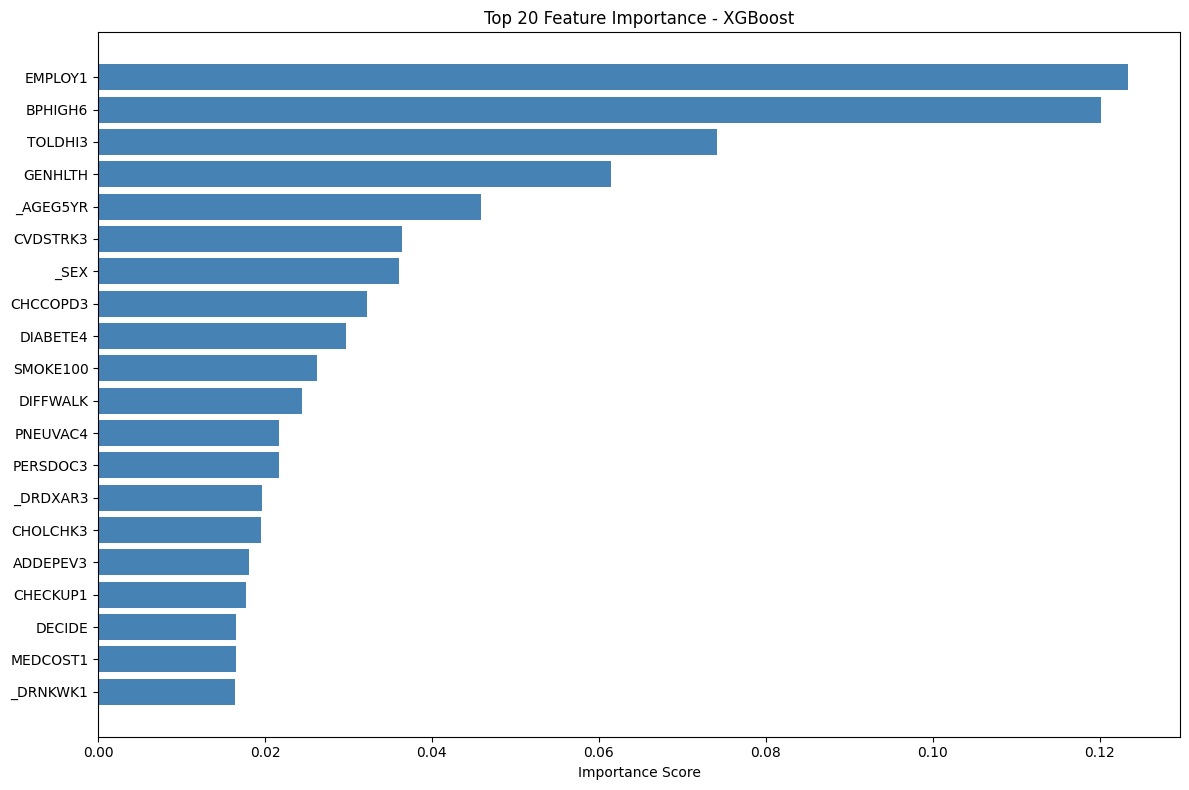

In [123]:
import matplotlib.pyplot as plt
# ── 1. Feature Importance dari model XGBoost yang sudah ditraining ──
importances = model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 Feature Importance:")
print(feat_imp_df.head(50))

# %%
# ── 2. Plot Feature Importance ──
plt.figure(figsize=(12, 8))
top_n = 20
plt.barh(
    feat_imp_df['feature'][:top_n][::-1],
    feat_imp_df['importance'][:top_n][::-1],
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

In [124]:
import numpy as np
from tqdm import tqdm
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import TomekLinks, NearMiss
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import pandas as pd
from sklearn.metrics import f1_score, recall_score, precision_score

# ── 1. Definisi kuartil & resamplers ────────────────────────────────────────
kuartils = [1, 2, 3]  # Q1=25%, Q2=50%, Q3=75%

resamplers = {
    # Baseline
    'scale_pos_weight'  : None,

    # Over-sampling
    'SMOTE'             : SMOTE(random_state=42),
    'BorderlineSMOTE'   : BorderlineSMOTE(random_state=42),
    'ADASYN'            : ADASYN(random_state=42),

    # Combine (over + under)
    'SMOTETomek'        : SMOTETomek(random_state=42),
    'SMOTEENN'          : SMOTEENN(random_state=42),

    # Under-sampling
    'TomekLinks'        : TomekLinks(n_jobs=-1),
    'NearMiss-1'        : NearMiss(version=1, n_jobs=-1),
    'NearMiss-2'        : NearMiss(version=2, n_jobs=-1),
    'NearMiss-3'        : NearMiss(version=3, n_jobs=-1),
}

# ── 2. Loop kuartil × resampler ─────────────────────────────────────────────
results_all = {}
confusion_matrices = {}
N_total = len(feat_imp_df)

outer_bar = tqdm(kuartils, desc="Kuartil", position=0)

for Q in outer_bar:
    N_FEATURES = int(np.ceil(N_total * Q / 4))  # 25%, 50%, 75%, 100%
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()

    X_train_q = X_train[selected_features]
    X_test_q  = X_test[selected_features]

    outer_bar.set_postfix({'fitur': N_FEATURES})

    inner_bar = tqdm(resamplers.items(), desc=f"  Resampler (Q={Q})", position=1, leave=False)

    for resampler_name, sampler in inner_bar:
        inner_bar.set_postfix({'method': resampler_name})

        if sampler is None:
            X_res, y_res = X_train_q, y_train
            spw = (y_train == 0).sum() / (y_train == 1).sum()
        else:
            X_res, y_res = sampler.fit_resample(X_train_q, y_train)
            spw = 1.0

        xgb_model_q = XGBClassifier(
            n_estimators     = 300,
            max_depth        = 6,
            learning_rate    = 0.05,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            scale_pos_weight = spw,
            eval_metric      = 'logloss',
            random_state     = 42,
            n_jobs           = -1
        )
        xgb_model_q.fit(X_res, y_res)

        y_pred = xgb_model_q.predict(X_test_q)
        y_prob = xgb_model_q.predict_proba(X_test_q)[:, 1]
        report = classification_report(y_test, y_pred, output_dict=True)
        cm     = confusion_matrix(y_test, y_pred)

        key = f'Q{Q}_{resampler_name}'

        results_all[key] = {
            'Kuartil'      : Q,
            'Label Kuartil': f'Q{Q} ({Q*25}%)',
            'N Fitur'      : N_FEATURES,
            'Resampler'    : resampler_name,

            # Macro (fair)
            'Recall Macro'    : recall_score(y_test, y_pred, average='macro'),
            'Precision Macro' : precision_score(y_test, y_pred, average='macro'),
            'F1 Macro'        : f1_score(y_test, y_pred, average='macro'),

            # Weighted (ikut distribusi)
            'Recall Weighted'    : recall_score(y_test, y_pred, average='weighted'),
            'Precision Weighted' : precision_score(y_test, y_pred, average='weighted'),
            'F1 Weighted'        : f1_score(y_test, y_pred, average='weighted'),

            # Micro (overall)
            'F1 Micro'  : f1_score(y_test, y_pred, average='micro'),

            'Accuracy'  : report['accuracy'],
            'AUC'       : roc_auc_score(y_test, y_prob),
        }

Kuartil: 100%|██████████| 3/3 [00:24<00:00,  8.15s/it, fitur=27]


In [126]:
# ── 3. Tabel hasil ───────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
results_df[['Kuartil', 'N Fitur']] = results_df[['Kuartil', 'N Fitur']].astype(int)

print("\n── Perbandingan Semua Kombinasi (sort by F1 Macro) ──")

cols_show = [
    'Label Kuartil', 'N Fitur', 'Resampler',

    # Overall (lebih fair)
    'Recall Macro', 'Precision Macro', 'F1 Macro',

    # Weighted (ikut distribusi data)
    'F1 Weighted',

    # Global
    'F1 Micro', 'Accuracy', 'AUC'
]

print(
    results_df[cols_show]
    .sort_values('F1 Macro', ascending=False)
    .to_string()
)


── Perbandingan Semua Kombinasi (sort by F1 Macro) ──
                    Label Kuartil  N Fitur         Resampler Recall Macro Precision Macro  F1 Macro F1 Weighted F1 Micro Accuracy       AUC
Q1_SMOTEENN              Q1 (25%)        9          SMOTEENN     0.678554        0.655189  0.665672    0.897226   0.8935   0.8935  0.840882
Q3_SMOTEENN              Q3 (75%)       27          SMOTEENN     0.667062         0.64183  0.652897    0.892571    0.888    0.888  0.840236
Q2_SMOTEENN              Q2 (50%)       18          SMOTEENN     0.720812        0.620246   0.64543      0.8707  0.84875  0.84875   0.84962
Q3_scale_pos_weight      Q3 (75%)       27  scale_pos_weight     0.727446        0.615063  0.639031    0.863597   0.8375   0.8375  0.842399
Q2_BorderlineSMOTE       Q2 (50%)       18   BorderlineSMOTE     0.609134        0.677657  0.632371    0.901254  0.91175  0.91175  0.843799
Q1_SMOTETomek            Q1 (25%)        9        SMOTETomek     0.666162        0.614018  0.632099    0.


Skenario : Q2_SMOTEENN | 9 fitur


Q2_SMOTEENN: 100%|██████████| 8/8 [00:07<00:00,  1.05it/s]



Skenario : Q3_SMOTEENN | 18 fitur


Q3_SMOTEENN: 100%|██████████| 8/8 [00:12<00:00,  1.57s/it]



── Perbandingan (sort by F1 Macro) ──
                                   Skenario   Kuartil               Model  N Fitur  F1 Macro    F1 CVD Recall CVD Precision CVD F1 Weighted Accuracy       AUC Specificity
Q2_SMOTEENN_XGBoost             Q2_SMOTEENN  Q1 (25%)             XGBoost        9  0.665672  0.389685    0.42236      0.361702    0.897226   0.8935  0.840882    0.934747
Q2_SMOTEENN_CatBoost            Q2_SMOTEENN  Q1 (25%)            CatBoost        9  0.661149  0.381766   0.416149      0.352632    0.895551   0.8915  0.843427    0.933116
Q2_SMOTEENN_LightGBM            Q2_SMOTEENN  Q1 (25%)            LightGBM        9  0.655808   0.36858   0.378882      0.358824    0.896793   0.8955  0.839721    0.940729
Q3_SMOTEENN_LightGBM            Q3_SMOTEENN  Q2 (50%)            LightGBM       18  0.650297  0.383562   0.565217      0.290271    0.874089  0.85375  0.848128     0.87901
Q2_SMOTEENN_GradientBoosting    Q2_SMOTEENN  Q1 (25%)    GradientBoosting        9  0.649199  0.378556   0

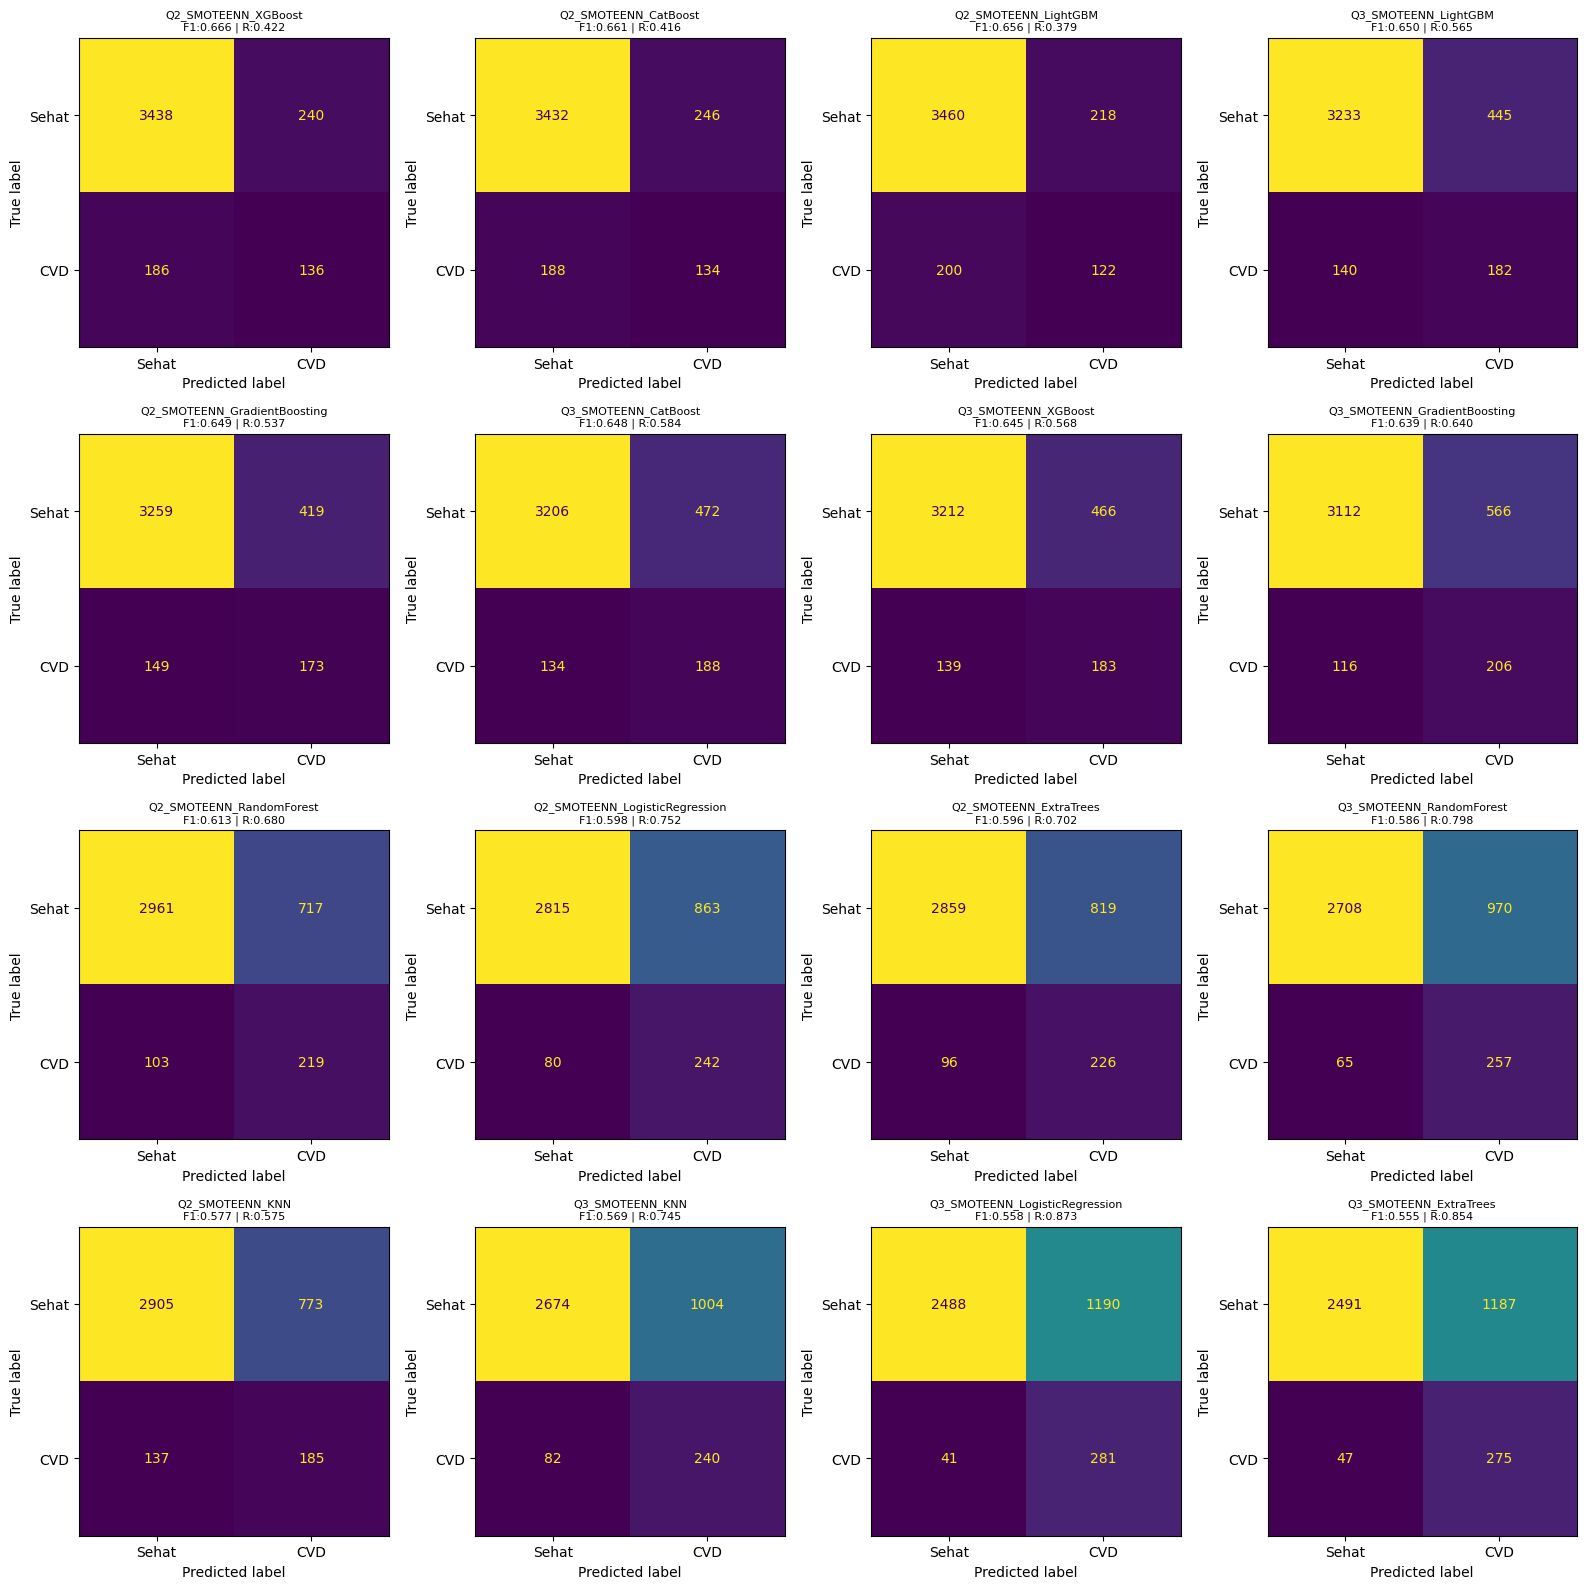

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from imblearn.combine import SMOTEENN
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier


# ── 1. SCENARIO ─────────────────────────────────────────────────────────────
scenarios = {
    'Q2_SMOTEENN': {
        'kuartil'   : 1,
        'resampler' : SMOTEENN(random_state=42),
    },
    'Q3_SMOTEENN': {
        'kuartil'   : 2,
        'resampler' : SMOTEENN(random_state=42),
    },
}


# ── 2. MODELS (FIXED PARAMS) ────────────────────────────────────────────────
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    ),

    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        random_state=42, verbose=0
    ),

    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=6,
        random_state=42, n_jobs=-1
    ),

    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=300, max_depth=6,
        random_state=42, n_jobs=-1
    ),

    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        random_state=42
    ),

    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=42
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
}


# ── 3. LOOP ─────────────────────────────────────────────────────────────────
results_all = {}
conf_matrices = {}
N_total = len(feat_imp_df)

for sc_name, sc_cfg in scenarios.items():

    N_FEATURES = int(np.ceil(N_total * sc_cfg['kuartil'] / 4))
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()

    X_train_sc = X_train[selected_features]
    X_test_sc  = X_test[selected_features]

    # Resampling
    if sc_cfg['resampler'] is None:
        X_res, y_res = X_train_sc, y_train
        spw = (y_train == 0).sum() / (y_train == 1).sum()
    else:
        X_res, y_res = sc_cfg['resampler'].fit_resample(X_train_sc, y_train)
        spw = 1.0

    print(f"\n{'='*60}")
    print(f"Skenario : {sc_name} | {N_FEATURES} fitur")
    print(f"{'='*60}")

    for model_name, clf in tqdm(models.items(), desc=sc_name):

        # Set imbalance handling
        if hasattr(clf, 'scale_pos_weight'):
            clf.set_params(scale_pos_weight=spw)

        if hasattr(clf, 'class_weight'):
            clf.set_params(class_weight='balanced' if spw > 1 else None)

        # Train
        clf.fit(X_res, y_res)

        # Predict
        y_pred = clf.predict(X_test_sc)

        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_sc)[:, 1]
        else:
            y_prob = np.zeros_like(y_pred)

        # Metrics
        recall_cvd    = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
        precision_cvd = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1_cvd        = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

        f1_macro    = f1_score(y_test, y_pred, average='macro', zero_division=0)
        f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        accuracy = np.mean(y_pred == y_test)

        try:
            auc = roc_auc_score(y_test, y_prob)
        except:
            auc = 0.5

        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        key = f"{sc_name}_{model_name}"

        results_all[key] = {
            'Skenario'      : sc_name,
            'Kuartil'       : f"Q{sc_cfg['kuartil']} ({sc_cfg['kuartil']*25}%)",
            'Model'         : model_name,
            'N Fitur'       : N_FEATURES,

            # MAIN
            'F1 Macro'      : f1_macro,

            # SUPPORT
            'F1 Weighted'   : f1_weighted,
            'F1 CVD'        : f1_cvd,
            'Recall CVD'    : recall_cvd,
            'Precision CVD' : precision_cvd,

            'Accuracy'      : accuracy,
            'AUC'           : auc,
            'Specificity'   : specificity,

            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        }

        conf_matrices[key] = cm


# ── 4. TABLE ────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)

results_df[['N Fitur','TN','FP','FN','TP']] = \
    results_df[['N Fitur','TN','FP','FN','TP']].astype(int)

cols_show = [
    'Skenario','Kuartil','Model','N Fitur',
    'F1 Macro','F1 CVD','Recall CVD',
    'Precision CVD','F1 Weighted',
    'Accuracy','AUC','Specificity'
]

print("\n── Perbandingan (sort by F1 Macro) ──")
print(results_df[cols_show].sort_values('F1 Macro', ascending=False).to_string())


# ── 5. BEST MODEL ───────────────────────────────────────────────────────────
best_idx = results_df['F1 Macro'].idxmax()
best = results_df.loc[best_idx]

print(f"\n✅ BEST MODEL:")
print(f"   Skenario : {best['Skenario']}")
print(f"   Model    : {best['Model']}")
print(f"   F1 Macro : {best['F1 Macro']}")
print(f"   F1 CVD   : {best['F1 CVD']}")
print(f"   Recall   : {best['Recall CVD']}")
print(f"   AUC      : {best['AUC']}")


# ── 6. CONFUSION MATRIX ─────────────────────────────────────────────────────
sorted_keys = results_df.sort_values('F1 Macro', ascending=False).index.tolist()

ncols = 4
nrows = int(np.ceil(len(sorted_keys) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))
axes = axes.flatten()

for i, key in enumerate(sorted_keys):
    cm = conf_matrices[key]
    row = results_all[key]

    disp = ConfusionMatrixDisplay(cm, display_labels=['Sehat','CVD'])
    disp.plot(ax=axes[i], colorbar=False)

    axes[i].set_title(
        f"{key}\nF1:{row['F1 Macro']:.3f} | R:{row['Recall CVD']:.3f}",
        fontsize=8
    )

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()